# SOC Prediction Model — Random Forest Regressor
This notebook trains a Random Forest model on the soil RGB dataset to predict Soil Organic Carbon (SOC). It evaluates performance using **9 metrics** and generates diagnostic plots.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score,
    max_error,
    median_absolute_error,
)
from sklearn.preprocessing import StandardScaler
import joblib

sns.set_theme(style='whitegrid', context='talk')
%matplotlib inline

## 1. Load & Prepare Data

In [2]:
df = pd.read_csv('soil_RGB_SOC_data.csv')
print(f'Dataset: {df.shape[0]} rows, {df.shape[1]} columns')

# Feature engineering – add Brightness
df['Brightness'] = (df['R'] + df['G'] + df['B']) / 3.0

X = df[['R', 'G', 'B', 'Brightness']]
y = df['SOC']

print(f'Features: {list(X.columns)}')
print(f'Target  : SOC')
df.head()

Dataset: 50000 rows, 4 columns
Features: ['R', 'G', 'B', 'Brightness']
Target  : SOC


,R,G,B,SOC,Brightness
0,0.341532,0.293612,0.244217,3.331952,0.293121
1,0.494881,0.449789,0.323566,2.400840,0.422746
2,0.274489,0.253412,0.188667,3.627119,0.238856
3,0.194135,0.173961,0.132181,4.020393,0.166759
4,0.661541,0.564222,0.467340,1.766361,0.564368


## 2. Train / Test Split (80-20)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Training samples : 40000
Testing  samples : 10000


## 3. Feature Scaling

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Train Random Forest Regressor

In [5]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_scaled, y_train)
print('Training complete.')

Training complete.


## 5. Predictions

In [6]:
y_pred_train = rf_model.predict(X_train_scaled)
y_pred_test  = rf_model.predict(X_test_scaled)

## 6. Evaluation Metrics (9 Metrics)

In [7]:
metrics = {
    'R² Score': r2_score(y_test, y_pred_test),
    'Adjusted R²': 1 - (1 - r2_score(y_test, y_pred_test)) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1),
    'MAE': mean_absolute_error(y_test, y_pred_test),
    'MSE': mean_squared_error(y_test, y_pred_test),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_test),
    'Median Abs Error': median_absolute_error(y_test, y_pred_test),
    'Explained Variance': explained_variance_score(y_test, y_pred_test),
    'Max Error': max_error(y_test, y_pred_test),
}

metrics_df = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
display(metrics_df)

# Overfitting check
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = metrics['R² Score']
print(f'\nTrain R²: {train_r2:.6f}  |  Test R²: {test_r2:.6f}')
if train_r2 - test_r2 > 0.05:
    print('⚠️  Possible overfitting detected (Train R² >> Test R²)')
else:
    print('✅  No significant overfitting detected.')

,Metric,Value
0,R² Score,0.878493
1,Adjusted R²,0.878444
2,MAE,0.284421
3,MSE,0.126292
4,RMSE,0.355375
5,MAPE,0.159066
6,Median Abs Error,0.244588
7,Explained Variance,0.878501
8,Max Error,1.444846



Train R²: 0.927174  |  Test R²: 0.878493
✅  No significant overfitting detected.


## 7. Feature Importance

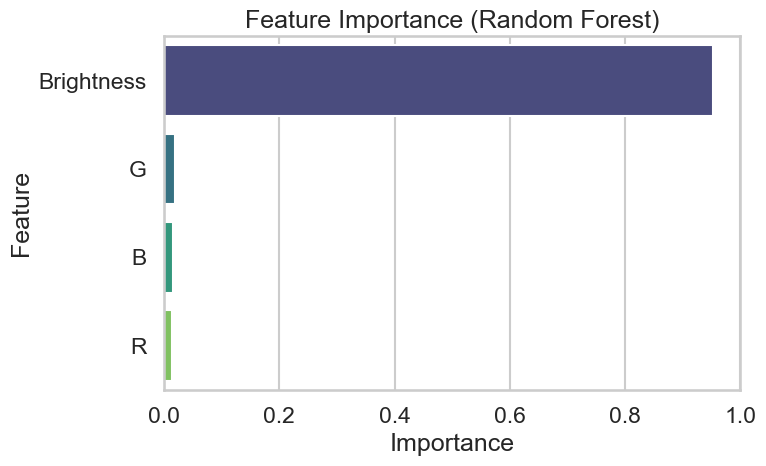

,Feature,Importance
3,Brightness,0.952476
1,G,0.019284
2,B,0.015139
0,R,0.013100


In [8]:
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

display(importance_df)

## 8. Actual vs Predicted (Density)

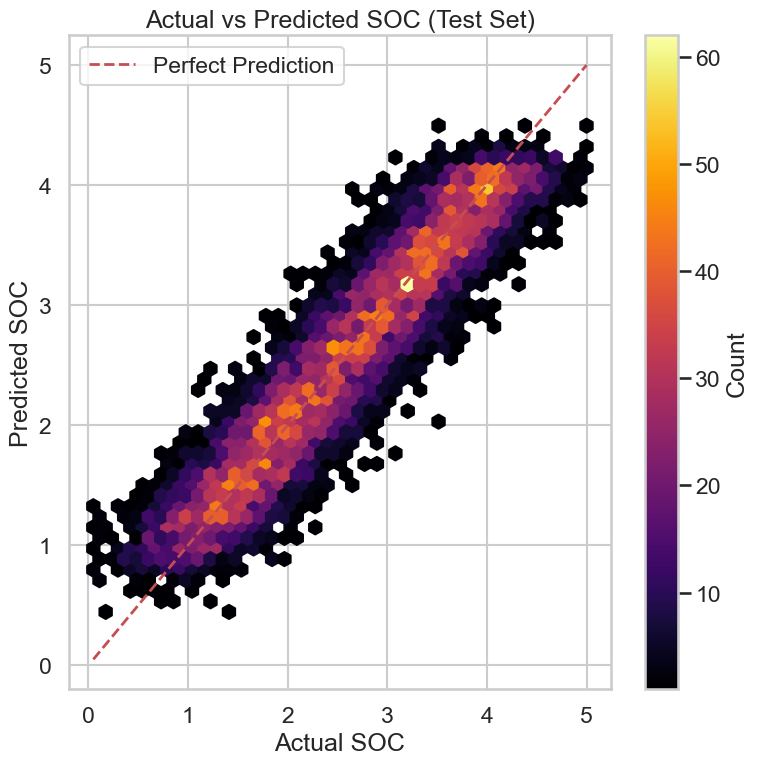

In [9]:
plt.figure(figsize=(8, 8))
plt.hexbin(y_test, y_pred_test, gridsize=40, cmap='inferno', mincnt=1)
plt.colorbar(label='Count')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual SOC')
plt.ylabel('Predicted SOC')
plt.title('Actual vs Predicted SOC (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Residual Analysis

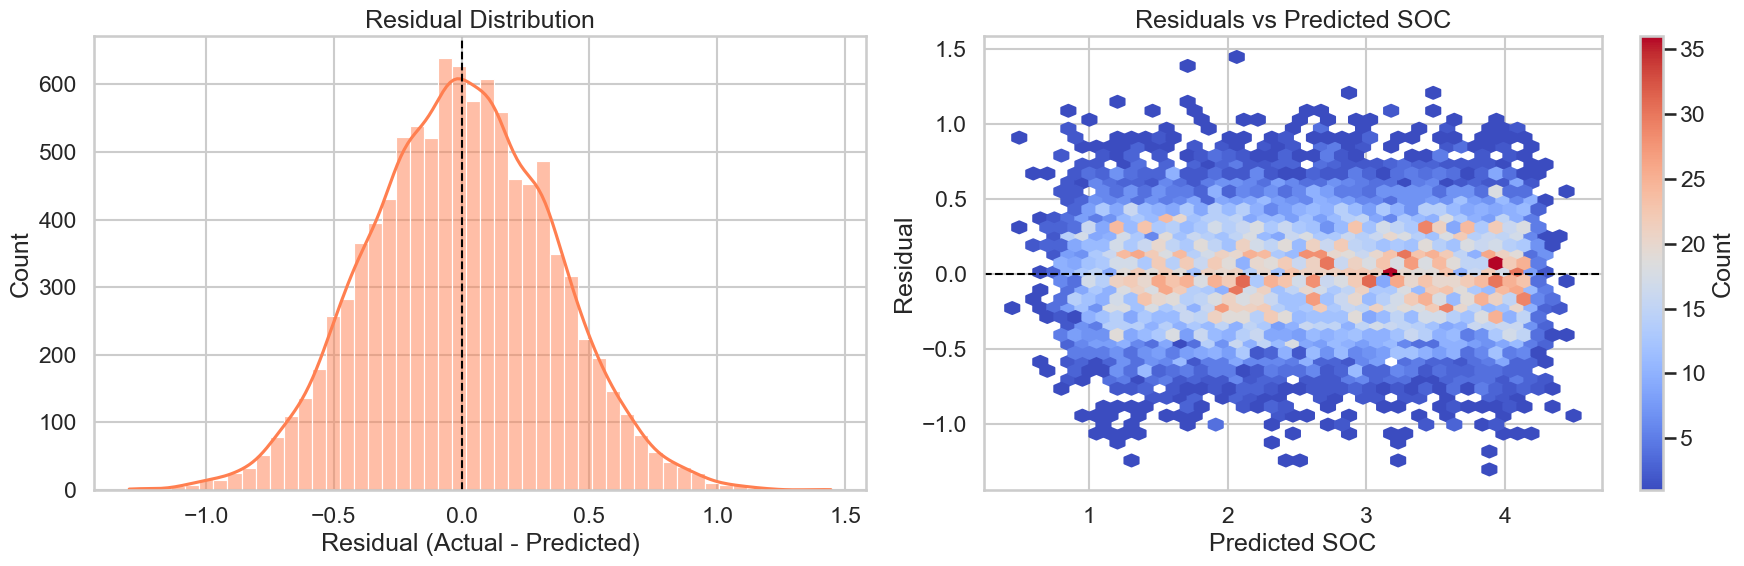

In [10]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Residual distribution
sns.histplot(residuals, kde=True, bins=50, color='coral', ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', lw=1.5)
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_title('Residual Distribution')

# Residuals vs Predicted
hb = axes[1].hexbin(y_pred_test, residuals, gridsize=40, cmap='coolwarm', mincnt=1)
fig.colorbar(hb, ax=axes[1], label='Count')
axes[1].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Predicted SOC')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted SOC')

plt.tight_layout()
plt.show()

## 10. Metrics Summary Chart

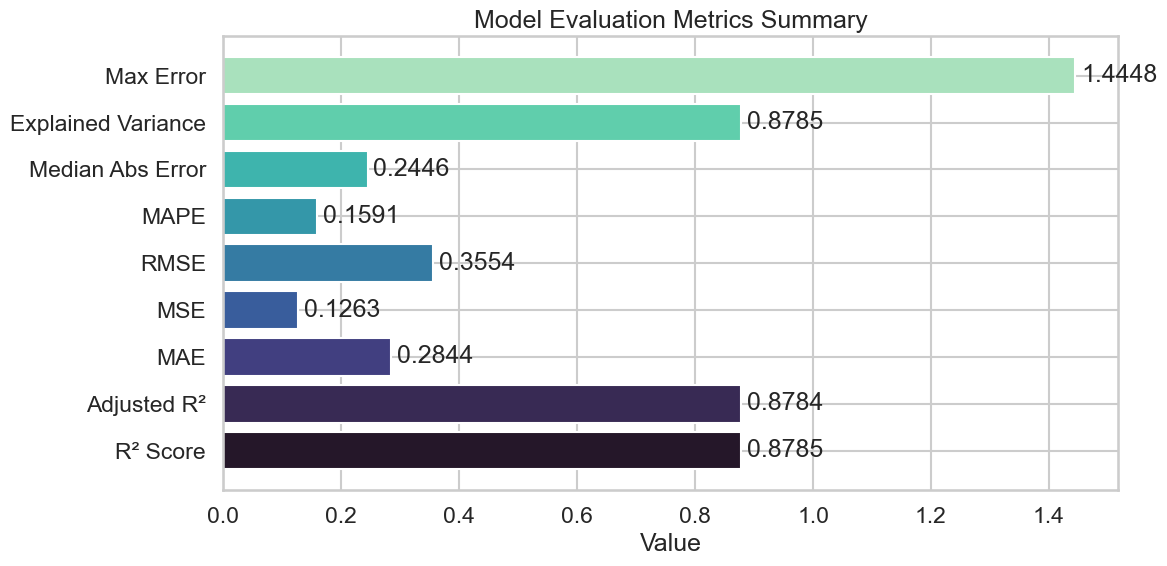

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(list(metrics.keys()), list(metrics.values()), color=sns.color_palette('mako', len(metrics)))
ax.set_xlabel('Value')
ax.set_title('Model Evaluation Metrics Summary')
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()

## 11. Save Model & Scaler

In [12]:
joblib.dump(rf_model, 'random_forest_SOC_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('Saved trained model  -> random_forest_SOC_model.pkl')
print('Saved fitted scaler  -> scaler.pkl')
print('\n✅ ALL DONE!')

Saved trained model  -> random_forest_SOC_model.pkl
Saved fitted scaler  -> scaler.pkl

✅ ALL DONE!
